# Connor's Models

In [85]:
import numpy as np
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.statespace.sarimax import SARIMAX
from itertools import product
from sklearn.metrics import root_mean_squared_error
from prophet.plot import plot_plotly, plot_components_plotly
from prophet.plot import add_changepoints_to_plot
warnings.filterwarnings("ignore")

## Prophet no Exog - 175.92457709598287

In [86]:
df = pd.read_csv('../train.csv')
df

,Datetime,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,GeneratorWinding1Temperature,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WindDirection,WindSpeed
0,2018-01-01 06:20:00+00:00,26.212347,28.696304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,252.00,3.976499,NaN,NaN,252.00,3.042750
1,2018-01-01 06:40:00+00:00,59.632658,29.052567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,255.00,11.091660,NaN,NaN,255.00,3.424814
2,2018-01-01 06:50:00+00:00,40.889650,28.984758,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,264.75,4.234497,NaN,NaN,264.75,3.507172
3,2018-01-01 10:40:00+00:00,34.398111,30.282058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,283.75,5.347792,NaN,NaN,283.75,3.442212
4,2018-01-01 12:00:00+00:00,29.797653,29.333519,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.00,6.022326,NaN,NaN,274.00,3.031363
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77197,2020-03-15 23:10:00+00:00,272.852287,23.500851,43.740629,-0.524250,-0.108540,-0.108540,63.668076,56.801410,1029.697556,64.904780,64.000634,35.012077,35.406250,182.00,54.889963,9.243551,2.0,182.00,5.156629
77198,2020-03-15 23:20:00+00:00,295.675931,23.409183,43.529209,-0.684376,-0.168882,-0.168882,63.361840,56.551527,1032.996150,64.109157,63.189782,35.004216,35.280933,182.00,60.673948,9.269149,2.0,182.00,5.257433
77199,2020-03-15 23:30:00+00:00,295.127333,23.336964,43.331115,-0.743521,-0.292512,-0.292512,63.156279,56.393276,1031.935870,63.740245,62.798514,35.003815,35.140925,182.00,59.551241,9.252811,2.0,182.00,5.188531
77200,2020-03-15 23:40:00+00:00,342.942216,23.310323,43.169442,-0.955621,-0.516466,-0.516466,63.191997,56.273992,1047.165900,63.657965,62.699627,35.003815,35.093750,182.00,69.460091,9.385111,2.0,182.00,5.408458


In [87]:
df.isna().sum()

Datetime                            0
ActivePower                         0
AmbientTemperatue                 896
BearingShaftTemperature         26684
Blade1PitchAngle                43282
Blade2PitchAngle                43365
Blade3PitchAngle                43365
GearboxBearingTemperature       26682
GearboxOilTemperature           26670
GeneratorRPM                    26674
GeneratorWinding1Temperature    26656
GeneratorWinding2Temperature    26649
HubTemperature                  26792
MainBoxTemperature              26704
NacellePosition                 20424
ReactivePower                      42
RotorRPM                        26680
TurbineStatus                   26466
WindDirection                   20424
WindSpeed                         308
dtype: int64

In [88]:
df['Datetime'] = pd.to_datetime(df['Datetime']).dt.tz_localize(None)
df.set_index('Datetime', inplace=True)

In [89]:
daily_df = df.resample('D').mean()
daily_df = daily_df.reset_index()
daily_df.head()

,Datetime,ActivePower,AmbientTemperatue,BearingShaftTemperature,Blade1PitchAngle,Blade2PitchAngle,Blade3PitchAngle,GearboxBearingTemperature,GearboxOilTemperature,GeneratorRPM,GeneratorWinding1Temperature,GeneratorWinding2Temperature,HubTemperature,MainBoxTemperature,NacellePosition,ReactivePower,RotorRPM,TurbineStatus,WindDirection,WindSpeed
0,2018-01-01,366.223561,25.528849,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,276.727612,74.042120,NaN,NaN,276.727612,5.263797
1,2018-01-02,462.550740,25.357526,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,274.105603,93.555723,NaN,NaN,274.105603,5.390719
2,2018-01-03,454.417752,24.379363,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,286.369130,91.627843,NaN,NaN,286.369130,5.295225
3,2018-01-04,369.952190,24.912347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,284.445471,74.360621,NaN,NaN,284.445471,5.094994
4,2018-01-05,319.446595,23.535679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,292.013293,64.366148,NaN,NaN,292.013293,4.915224


In [90]:
daily_df['ds'] = daily_df['Datetime']
daily_df['y'] = daily_df['ActivePower']
df_prophet = daily_df[['ds', 'y']]
df_prophet

,ds,y
0,2018-01-01,366.223561
1,2018-01-02,462.550740
2,2018-01-03,454.417752
3,2018-01-04,369.952190
4,2018-01-05,319.446595
...,...,...
800,2020-03-11,466.289248
801,2020-03-12,570.315539
802,2020-03-13,619.637333
803,2020-03-14,800.312824


In [91]:
df_prophet.isna().sum()

ds     0
y     71
dtype: int64

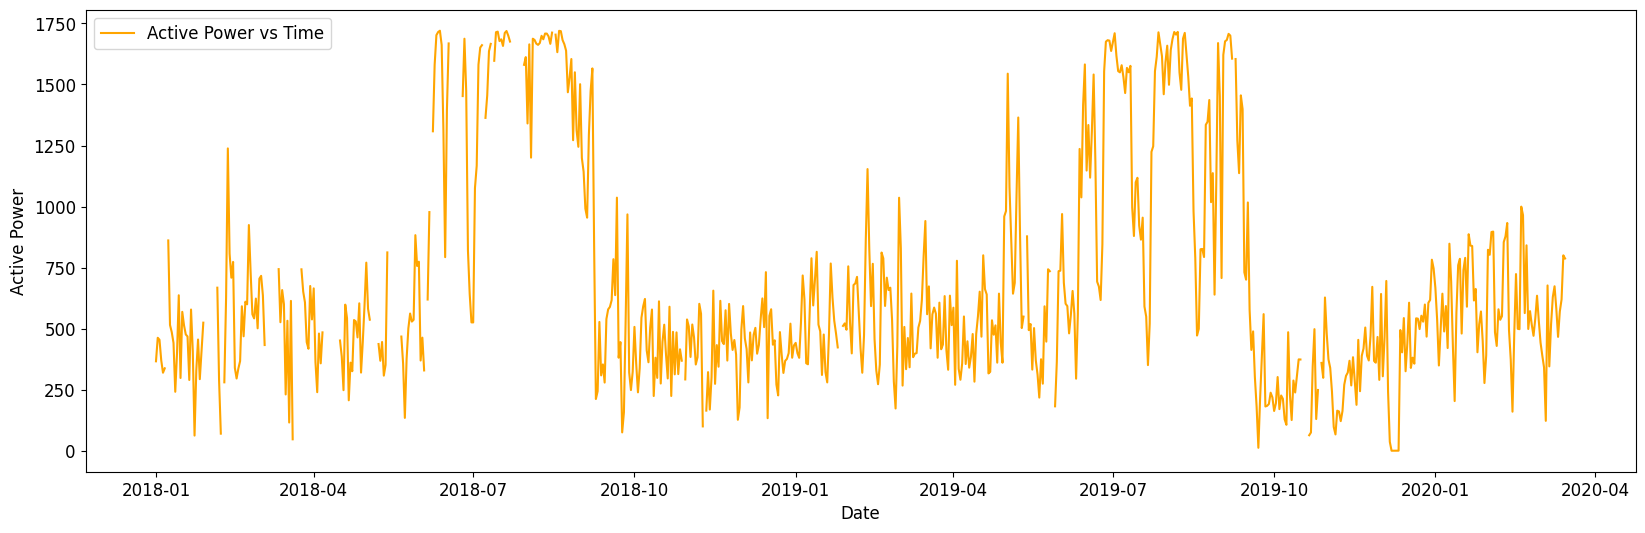

In [92]:
plt.rc('font', size=12)
fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(df_prophet.ds, df_prophet.y, color='orange', label='Active Power vs Time')
ax.set_xlabel('Date')
ax.set_ylabel('Active Power')
ax.legend(loc='upper left')

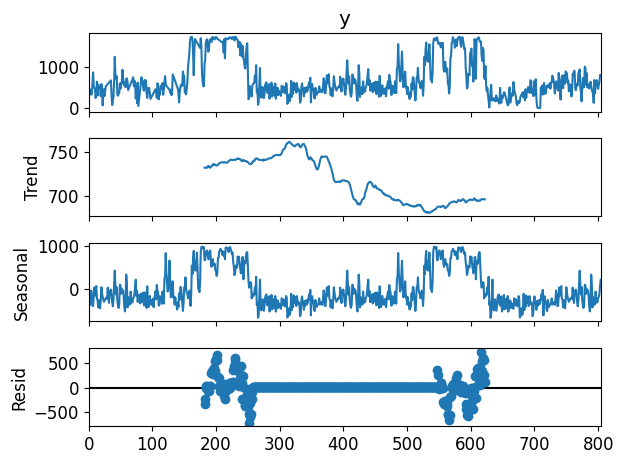

In [93]:
temp_y = df_prophet['y'].interpolate(method='linear').bfill().ffill()

res = sm.tsa.seasonal_decompose(temp_y, period=365)
fig = res.plot()
plt.show()

We only have 2 years of data and a strong yearly seasonality, so I don't want to take a large validation set and compromise the model. Since the goal is to predict 15 days, I will just leave out 15 days to validate with. 

In [94]:
df_train = df_prophet.iloc[:-15]
df_val = df_prophet.iloc[-15:]

In [102]:
changepoint_prior_scale=0.054 # 6 points
changepoint_prior_scale=0.05 # 5 points
changepoint_prior_scale=0.03 # 4 points
changepoint_prior_scale=0.025 # 2 points
changepoint_prior_scale=0.021 # 1 points
changepoint_prior_scales = [0.021, 0.025, 0.03, 0.05, 0.054]

for cps in changepoint_prior_scales:
    m = Prophet(weekly_seasonality=False, changepoint_prior_scale=cps)
    m.fit(df_train)
    future = m.make_future_dataframe(periods=15)
    forecast = m.predict(future)
    preds = forecast['yhat'][-15:]
    rmse = root_mean_squared_error(df_val['y'], preds)
    print(f'RMSE for cps={cps}: {rmse}')

11:23:48 - cmdstanpy - INFO - Chain [1] start processing
11:23:48 - cmdstanpy - INFO - Chain [1] done processing
11:23:48 - cmdstanpy - INFO - Chain [1] start processing
11:23:48 - cmdstanpy - INFO - Chain [1] done processing
11:23:48 - cmdstanpy - INFO - Chain [1] start processing
11:23:48 - cmdstanpy - INFO - Chain [1] done processing


RMSE for cps=0.021: 175.92457709598287
RMSE for cps=0.025: 176.1686007489407
RMSE for cps=0.03: 176.64847103235792


11:23:48 - cmdstanpy - INFO - Chain [1] start processing
11:23:48 - cmdstanpy - INFO - Chain [1] done processing
11:23:48 - cmdstanpy - INFO - Chain [1] start processing
11:23:48 - cmdstanpy - INFO - Chain [1] done processing


RMSE for cps=0.05: 177.32363500634665
RMSE for cps=0.054: 177.27058649234655


11:23:33 - cmdstanpy - INFO - Chain [1] start processing
11:23:33 - cmdstanpy - INFO - Chain [1] done processing


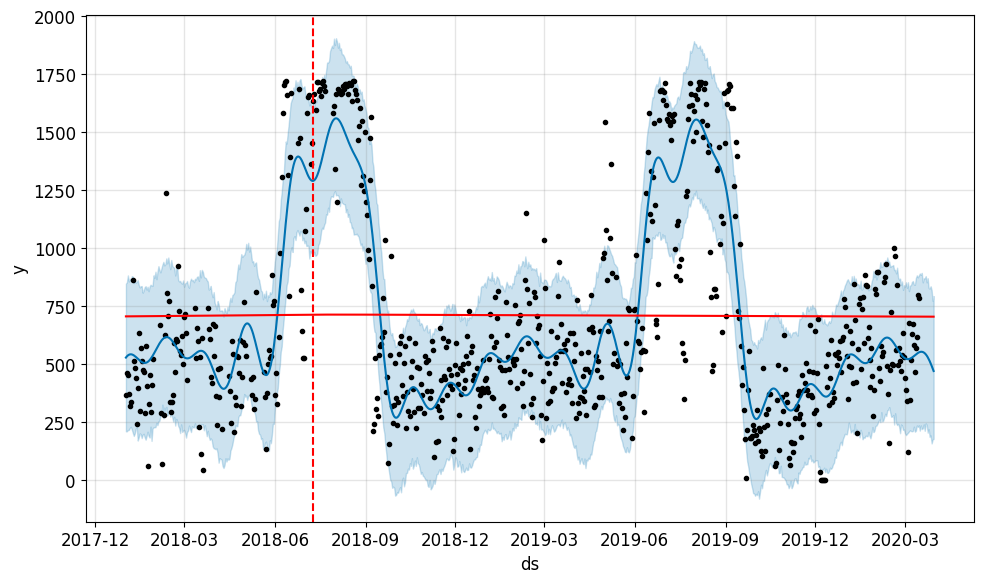

In [98]:
m = Prophet(weekly_seasonality=False, changepoint_prior_scale=0.021)
m.fit(df_prophet)
future = m.make_future_dataframe(periods=15)
forecast = m.predict(future)
fig = m.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), m, forecast)

In [99]:
plot_components_plotly(m, forecast)